In [1]:
from collections.abc import Mapping
from pathlib import Path
from datetime import datetime, timedelta
from textwrap import fill

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from matplotlib.legend import Legend
from matplotlib.legend_handler import HandlerLine2D
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnnotationBbox, DrawingArea
from matplotlib.patches import Polygon
from matplotlib.text import Text
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.transforms import Transform

In [2]:
def _draw_nodes(
    ax: Axes,
    nodes_df: pd.DataFrame,
    scale: float,
    base_node_sizes: Mapping[str, float],
    recombinant_font_ratio: float,
) -> None:
    outside_positions = {
        "top": (0, 20),
        "bottom": (0, -25),
        "left": (-25, 0),
        "right": (25, 0),
    }
    for _, node in nodes_df.iterrows():
        marker = "s" if node["type"] in ("sample", "clade") else "o"
        ax.scatter(
            node["x"],
            node["y"],
            marker=marker,
            s=(base_node_sizes[node["type"]] * scale)**2,
            facecolor="none" if node["color"] == "transparent" else node["color"],
            edgecolor="none" if node["type"] in ("clade", "internal", "anchor") else "black",
            linewidth=0 if node["type"] in ("clade", "internal", "anchor") else 1.5 * scale,
            zorder=3,
        )
        label_inside = "R" if node["type"] == "recombinant" else node["label_inside"]
        if pd.notna(label_inside):
            ax.text(
                node["x"],
                node["y"],
                label_inside,
                ha="center",
                va="center",
                fontsize=(
                    recombinant_font_ratio * base_node_sizes["recombinant"]
                    if node["type"] == "recombinant"
                    else 11
                ) * scale,
                fontweight=(
                    "bold"
                    if node["type"] == "recombinant"
                    else "normal"
                ),
                color=(
                    "white"
                    if node["type"] == "recombinant" or node["color"] == "black"
                    else "black"
                ),
                zorder=4,
            )
        if pd.notna(node["label_outside"]):
            dx, dy = outside_positions[node["outside_pos"]]
            ax.annotate(
                fill(node["label_outside"], width=14),
                (
                    node["x"],
                    node["y"],
                ),
                xytext=(
                    dx * scale,
                    dy * scale,
                ),
                textcoords="offset points",
                ha="center",
                va="center",
                multialignment="center",
                fontsize=11 * scale,
                zorder=4,
            )


def _draw_edges(
    ax: Axes,
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
    scale: float,
) -> None:
    mutation_width = 12 * scale
    mutation_thickness = 3 * scale
    mutation_spacing = 6.7 * scale

    for _, edge in edges_df.iterrows():
        parent = nodes_df.loc[edge["parent"]]
        child = nodes_df.loc[edge["child"]]
        ax.plot(
            [parent["x"], child["x"]],
            [parent["y"], child["y"]],
            linestyle=edge["style"],
            color=edge["color"],
            linewidth=1.8 * scale,
            zorder=1,
        )
        if not edge["num_mutations"]:
            continue
        parent_screen = ax.transData.transform((parent["x"], parent["y"]))
        child_screen = ax.transData.transform((child["x"], child["y"]))
        dx, dy = child_screen - parent_screen
        length = (dx**2 + dy**2)**0.5
        if length > 0:
            ux = dx / length
            uy = dy / length
            px = -uy
            py = ux
            for i in range(edge["num_mutations"]):
                offset = (i - (edge["num_mutations"] - 1) / 2) * mutation_spacing
                box_size = mutation_width + mutation_thickness
                center = box_size / 2
                corners = [
                    (
                        center + across * mutation_width / 2 * px
                            + along * mutation_thickness / 2 * ux,
                        center + across * mutation_width / 2 * py
                            + along * mutation_thickness / 2 * uy,
                    )
                    for across, along in [(-1, -1), (1, -1), (1, 1), (-1, 1)]
                ]
                drawing = DrawingArea(box_size, box_size, 0, 0)
                drawing.add_artist(Polygon(
                    corners,
                    closed=True,
                    facecolor="black",
                    edgecolor="none",
                ))
                ax.add_artist(AnnotationBbox(
                    drawing,
                    (
                        (parent["x"] + child["x"]) / 2,
                        (parent["y"] + child["y"]) / 2,
                    ),
                    xybox=(
                        offset * ux,
                        offset * uy,
                    ),
                    xycoords="data",
                    boxcoords="offset points",
                    box_alignment=(0.5, 0.5),
                    frameon=False,
                    pad=0,
                    zorder=2,
                ))


def _add_legend(
    ax: Axes,
    scale: float,
    wide: bool,
    recombinant_size: float,
    recombinant_font_ratio: float,
) -> None:
    legend_scale = 1.2 * scale

    class RecombinantLegendHandler(HandlerLine2D):
        def create_artists(
            self,
            legend: Legend,
            orig_handle: Line2D,
            xdescent: float,
            ydescent: float,
            width: float,
            height: float,
            fontsize: float,
            trans: Transform,
        ) -> list[Artist]:
            artists: list[Artist] = list(
                super().create_artists(
                    legend,
                    orig_handle,
                    xdescent,
                    ydescent,
                    width,
                    height,
                    fontsize,
                    trans,
                )
            )
            artists.append(
                Text(
                    x=width / 2 - xdescent,
                    y=height / 2 - ydescent,
                    text="R",
                    color="white",
                    fontsize=recombinant_font_ratio * orig_handle.get_markersize(),
                    fontweight="bold",
                    ha="center",
                    va="center",
                    transform=trans,
                )
            )
            return artists

    recombinant_handle = Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=12 * recombinant_size * legend_scale,
        markeredgewidth=legend_scale,
        label="Recombinant",
    )
    legend_handles = [
        Line2D(
            [],
            [],
            marker="s",
            linestyle="none",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=12 * legend_scale,
            markeredgewidth=legend_scale,
            label="Sample",
        ),
        Line2D(
            [],
            [],
            marker="s",
            linestyle="none",
            markerfacecolor="lightgray",
            markeredgecolor="none",
            markersize=8 * legend_scale,
            markeredgewidth=legend_scale,
            label="Collapsed clade",
        ),
        recombinant_handle,
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            markerfacecolor="lightgray",
            markeredgecolor="none",
            markersize=8 * legend_scale,
            markeredgewidth=legend_scale,
            label="Internal node",
        ),
        Line2D(
            [],
            [],
            marker=[
                (-0.125, -0.5),
                (0.125, -0.5),
                (0.125, 0.5),
                (-0.125, 0.5),
                (-0.125, -0.5),
            ],
            linestyle="none",
            markerfacecolor="black",
            markeredgecolor="none",
            markersize=12 * legend_scale,
            markeredgewidth=legend_scale,
            label="Mutation",
        ),
    ]
    ax.legend(
        handles=legend_handles,
        loc="upper left",
        bbox_to_anchor=(0, 0.10),
        ncol=3 if wide else 1,
        frameon=False,
        labelspacing=0.8,
        handlelength=2,
        handletextpad=0.8,
        fontsize=10 * legend_scale,
        handler_map={recombinant_handle: RecombinantLegendHandler()},
    )


def _format_axes(
    ax: Axes,
    reference_date: datetime,
    axes_height: float,
    scale: float,
    title: str,
    title_x: float,
) -> None:
    date_tick_count = max(2, min(12, int(axes_height * 72 / (28 * scale))))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=date_tick_count, integer=True))
    ax.yaxis.set_major_formatter(FuncFormatter(
        lambda y, position: (reference_date - timedelta(days=y)).strftime("%Y-%m-%d")
    ))
    ax.set_ylabel("")
    ax.xaxis.set_visible(False)
    for spine in ("top", "right", "bottom"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.tick_params(
        axis="y",
        length=4 * scale,
        pad=6 * scale,
        width=0.8 * scale,
        labelsize=10 * scale,
    )
    ax.spines["left"].set_linewidth(0.8 * scale)
    ax.set_title(
        title,
        fontsize=16 * scale,
        pad=15 * scale,
        loc="left",
        ha="left",
        x=title_x,
    )


def create_subgraph(
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
    reference_date: datetime,
    ax: Axes,
    relative_size: float = 1.1,
    title: str | None = None,
    show_legend: bool = False,
    title_x: float = 0.0,
    shared_scale: float | None = None,
) -> Axes:
    if title is None:
        title = ""

    circle_diameter = 700**0.5
    recombinant_size = 0.8  # Diameter relative to original circle size
    square_side = circle_diameter
    recombinant_font_ratio = 0.65  # Font size relative to circle diameter

    base_node_sizes = {
        "sample": square_side,
        "clade": square_side / 1.5,
        "recombinant": circle_diameter * recombinant_size,
        "internal": circle_diameter / 1.5,
        "anchor": circle_diameter,
    }

    figsize = tuple(ax.figure.get_size_inches())
    wide = figsize[0] >= figsize[1]
    xspan = max(float(nodes_df["x"].max() - nodes_df["x"].min()), 1)
    yspan = max(float(nodes_df["y"].max() - nodes_df["y"].min()), 1)
    ax.set(
        xlim=(
            nodes_df["x"].min() - 0.08 * xspan,
            nodes_df["x"].max() + 0.20 * xspan,
        ),
        ylim=(
            nodes_df["y"].min() - 0.08 * yspan,
            nodes_df["y"].max() + 0.08 * yspan,
        ),
        aspect="auto",
    )
    axes_width = ax.get_position().width * figsize[0]
    axes_height = ax.get_position().height * figsize[1]
    scale = (
        relative_size * min(axes_width / 7.48, axes_height / 6.7)
        if shared_scale is None
        else shared_scale
    )

    _draw_nodes(ax, nodes_df, scale, base_node_sizes, recombinant_font_ratio)
    _draw_edges(ax, nodes_df, edges_df, scale)
    if show_legend:
        _add_legend(
            ax,
            scale,
            wide,
            recombinant_size,
            recombinant_font_ratio,
        )
    _format_axes(ax, reference_date, axes_height, scale, title, title_x)

    return ax

In [3]:
data_dir = Path(".")
node_col_types = {
    "id": int,
    "type": str,
    "color": str,
    "label_inside": str,
    "label_outside": str,
    "x": float,
    "y": float,
}
edge_col_types = {
    "id": int,
    "parent": int,
    "child": int,
    "style": str,
    "color": str,
    "num_mutations": int,
}

In [4]:
def get_layout_data(
    nodes_file: str | Path,
    edges_file: str | Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    nodes_df = pd.read_csv(
        nodes_file,
        dtype=node_col_types,
        keep_default_na=False,
        na_values=["NA"],
    ).set_index("id", drop=False)
    nodes_df.loc[nodes_df["type"] == "anchor", "y"] += 20
    nodes_df.loc[nodes_df["type"] == "clade", "y"] -= 15
    nodes_df["x"] = nodes_df["x"] * 100 + 80

    edges_df = pd.read_csv(
        edges_file,
        dtype=edge_col_types,
    )

    return (nodes_df, edges_df)

In [5]:
xa_nodes_df, xa_edges_df = get_layout_data(
    data_dir / "XA_nodes.csv",
    data_dir / "XA_edges.csv",
)
xn_nodes_df, xn_edges_df = get_layout_data(
    data_dir / "XN-XAU_nodes.csv",
    data_dir / "XN-XAU_edges.csv",
)
xx_nodes_df, xx_edges_df = get_layout_data(
    data_dir / "XAA-XAB-XAG-XAM-XQ-XR-XU_nodes.csv",
    data_dir / "XAA-XAB-XAG-XAM-XQ-XR-XU_edges.csv",
)

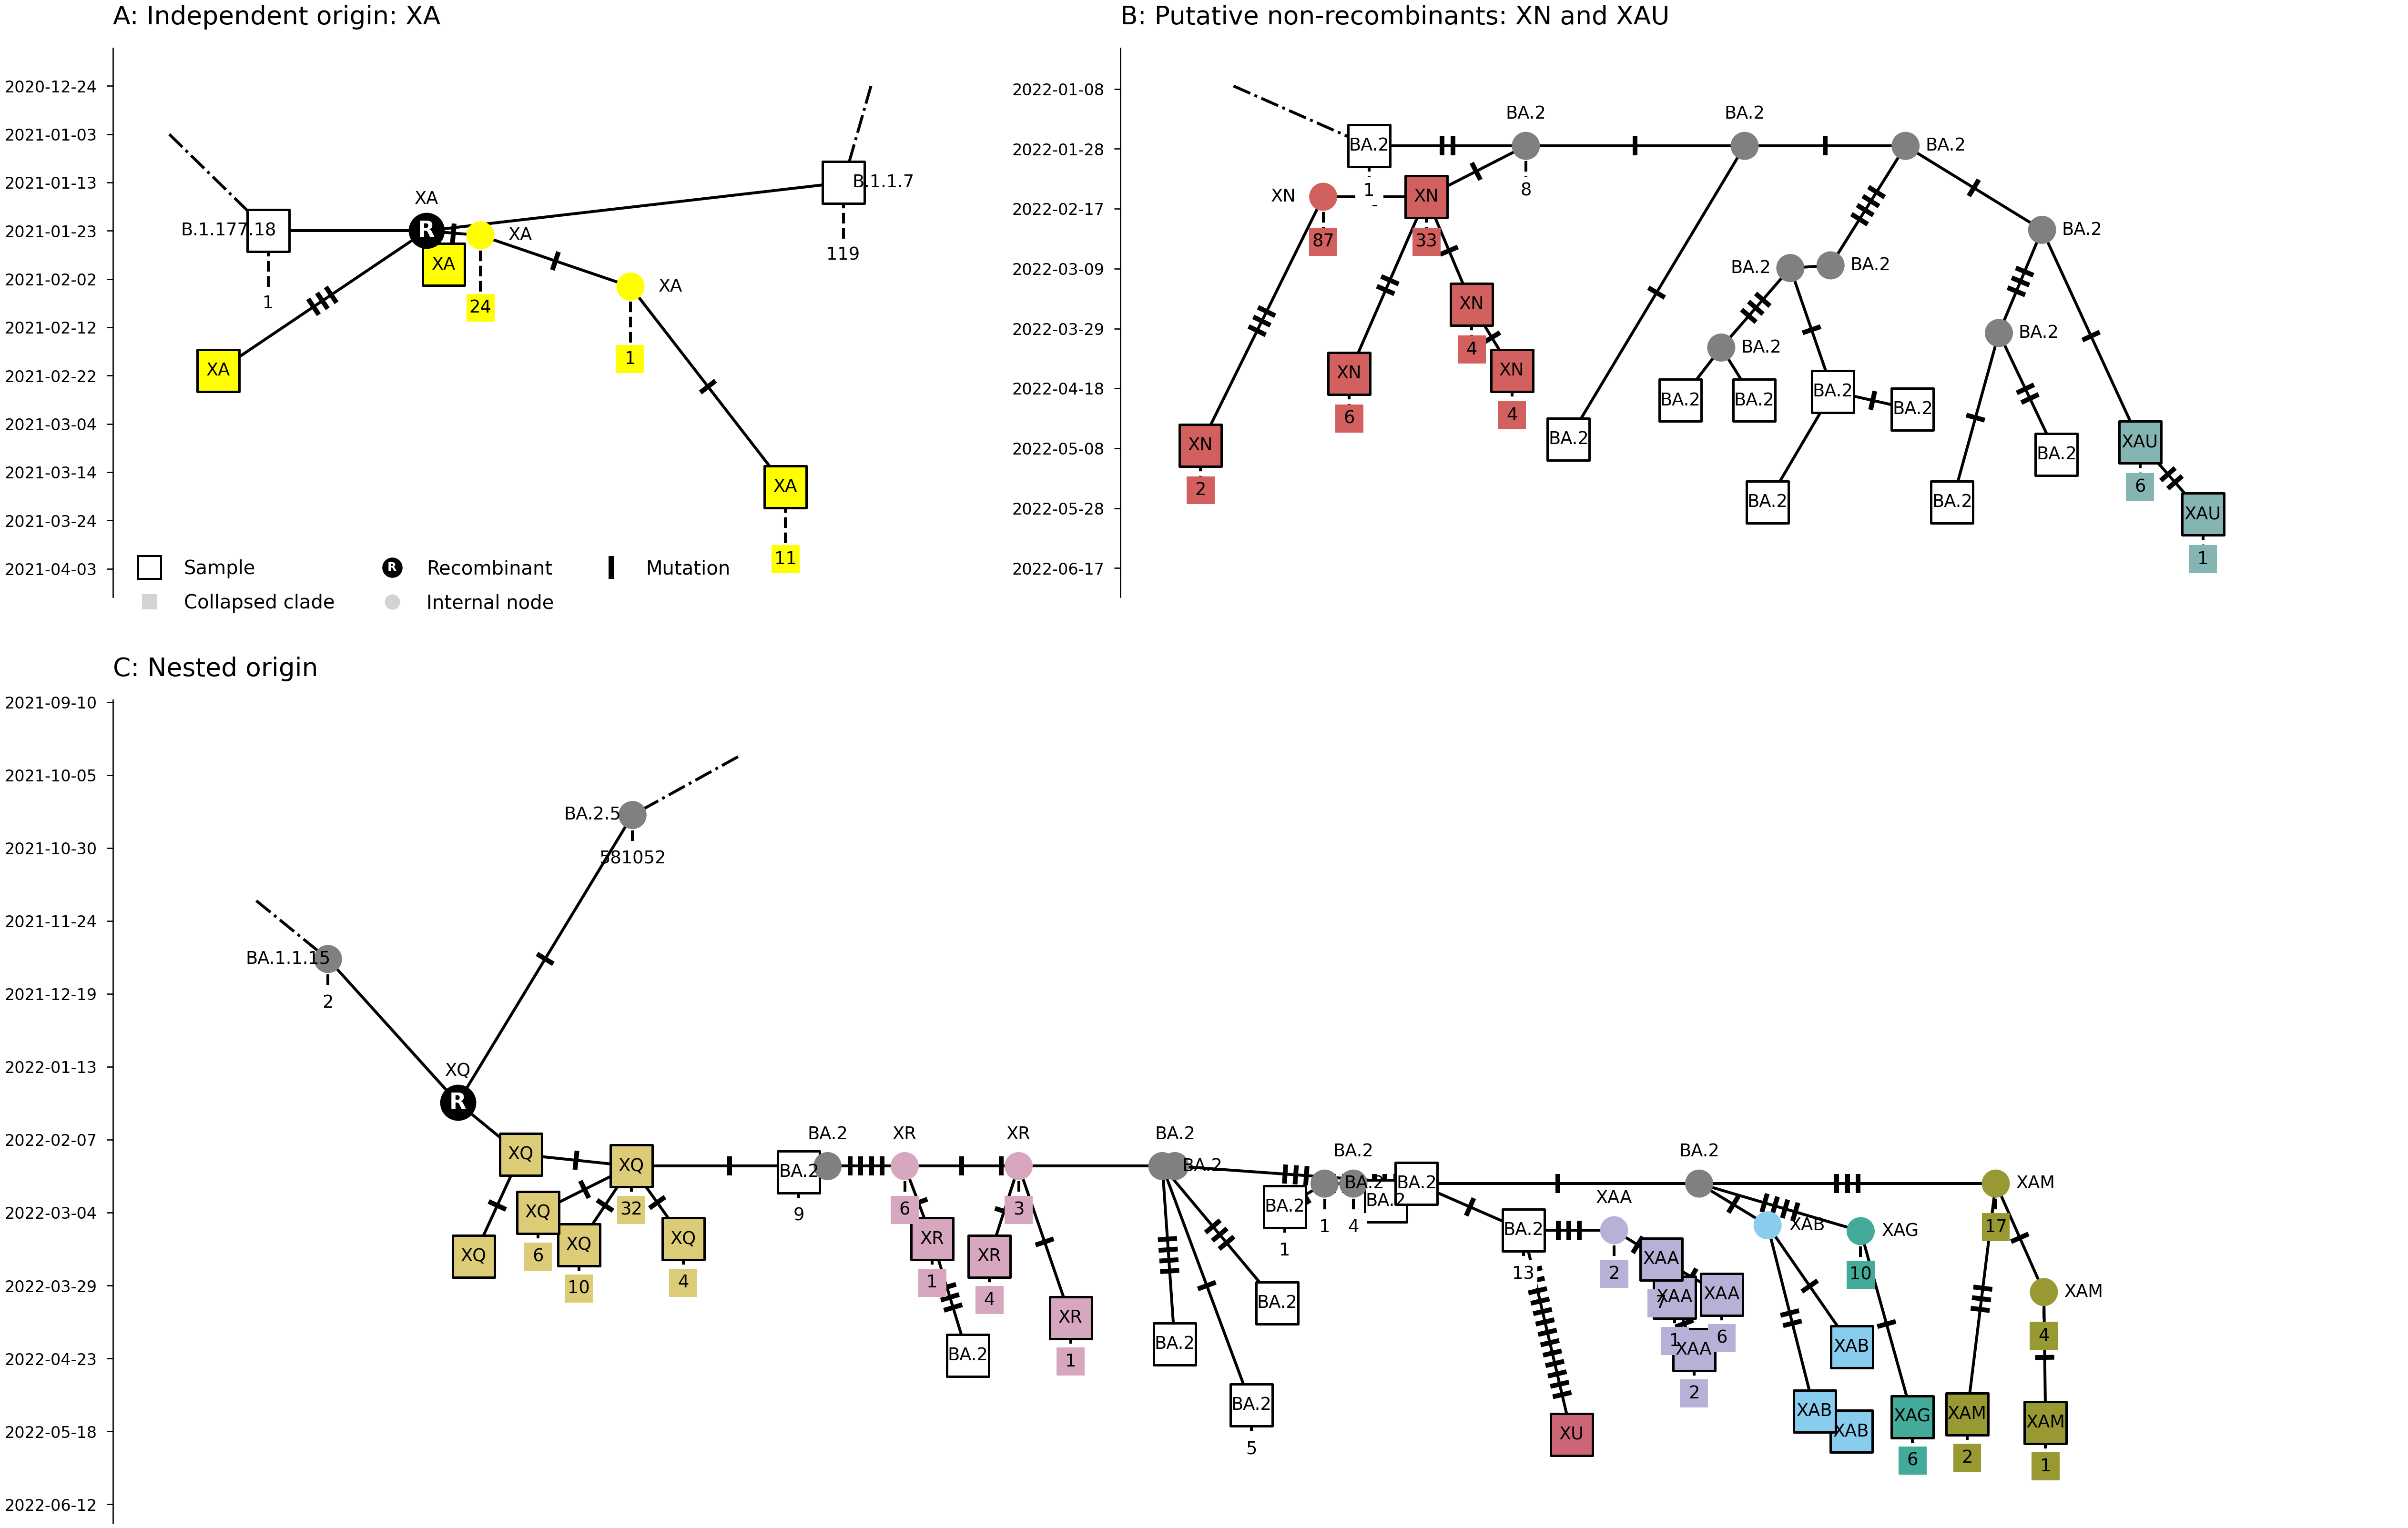

In [6]:
fig = plt.figure(figsize=(54, 36), layout="none")

top_width_ratios = [2.8, 4]
panel_height_ratios = [1, 1.5]  # Top row, bottom row
gs = fig.add_gridspec(
    2, 2,
    width_ratios=top_width_ratios,
    height_ratios=panel_height_ratios,
    left=0.08, right=0.97,
    top=0.94, bottom=0.08,
    wspace=0.1, hspace=0.15,
)

axes = [
    fig.add_subplot(gs[0, 0]),  # Top left
    fig.add_subplot(gs[0, 1]),  # Top right
    fig.add_subplot(gs[1, :]),  # Bottom, full width
]

relative_size = 1.4
figure_width, figure_height = fig.get_size_inches()
shared_scale = relative_size * min(
    min(ax.get_position().width * figure_width / 7.48,
        ax.get_position().height * figure_height / 6.7)
    for ax in axes
)

for ax, nodes, edges, title, show_legend in zip(
    axes,
    [xa_nodes_df, xn_nodes_df, xx_nodes_df],
    [xa_edges_df, xn_edges_df, xx_edges_df],
    [
        "A: Independent origin: XA",
        "B: Putative non-recombinants: XN and XAU",
        "C: Nested origin",
    ],
    [True, False, False],
):
    create_subgraph(
        nodes,
        edges,
        reference_date=datetime(2024, 6, 6),
        ax=ax,
        shared_scale=shared_scale,
        title=title,
        show_legend=show_legend,
    )

plt.show()